### 1. Prepare data for generation.


In [67]:
import pandas as pd

In [68]:
df_users = pd.read_csv('users.csv',sep=",")
df_users_feedback = pd.read_csv('users_feedback.csv',sep=",")
df_workouts = pd.read_csv('workouts.csv',sep=",")

df_workouts = df_workouts.drop(['program_name', 'gender', 'location'], axis=1)

### 2. Combine `df_users`, `df_users_feedback`, `df_workout_programs` into one table.

In [69]:
user_workout = pd.merge(df_workouts, df_users, on='program_id', how='inner')

In [70]:
print(user_workout.columns)
len(user_workout.columns)

Index(['program_id', 'day', 'exercise_name', 'sets', 'min_reps', 'max_reps',
       'difficulty', 'muscle_group', 'user_id', 'age', 'gender',
       'experience_level', 'experience_numeric', 'days_per_week', 'goal',
       'location', 'program_name', 'program_difficulty',
       'program_days_per_week'],
      dtype='object')


19

In [71]:
full_data = pd.merge(user_workout, df_users_feedback, on=['user_id', 'program_id'], how = 'inner')

In [72]:
print(full_data.columns)
len(full_data.columns)

Index(['program_id', 'day', 'exercise_name', 'sets', 'min_reps', 'max_reps',
       'difficulty', 'muscle_group', 'user_id', 'age', 'gender',
       'experience_level', 'experience_numeric', 'days_per_week', 'goal',
       'location', 'program_name', 'program_difficulty',
       'program_days_per_week', 'start_weight_kg', 'end_weight_kg',
       'goal_achieved', 'user_rating'],
      dtype='object')


23

In [73]:
print(full_data.isnull().sum())

program_id               0
day                      0
exercise_name            0
sets                     0
min_reps                 0
max_reps                 0
difficulty               0
muscle_group             0
user_id                  0
age                      0
gender                   0
experience_level         0
experience_numeric       0
days_per_week            0
goal                     0
location                 0
program_name             0
program_difficulty       0
program_days_per_week    0
start_weight_kg          0
end_weight_kg            0
goal_achieved            0
user_rating              0
dtype: int64


In [74]:
full_data['program_name'] = full_data['program_name'].str.replace(r'\s+[A-C]$', '', regex=True)

In [75]:
print(full_data['location'].unique())

['gym' 'home' 'street']


In [76]:
full_data

,program_id,day,exercise_name,sets,min_reps,max_reps,difficulty,muscle_group,user_id,age,...,days_per_week,goal,location,program_name,program_difficulty,program_days_per_week,start_weight_kg,end_weight_kg,goal_achieved,user_rating
0,1,Day 1,Bench Press,3,8,10,beginner,Chest,1,23,...,3,mass,gym,Full Body,beginner,3,78.5,82.0,True,4.7
1,1,Day 1,Bench Press,3,8,10,beginner,Chest,31,49,...,3,mass,gym,Full Body,beginner,3,79.0,82.5,True,4.7
2,1,Day 1,Bench Press,3,8,10,beginner,Chest,67,24,...,3,mass,gym,Full Body,beginner,3,79.5,83.0,True,4.8
3,1,Day 1,Bent-Over Barbell Row,3,8,10,intermediate,Back,1,23,...,3,mass,gym,Full Body,beginner,3,78.5,82.0,True,4.7
4,1,Day 1,Bent-Over Barbell Row,3,8,10,intermediate,Back,31,49,...,3,mass,gym,Full Body,beginner,3,79.0,82.5,True,4.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1233,30,Day 1,Leg Extension Side,4,12,16,intermediate,Glutes,87,30,...,6,mass,home,Barre Workout,intermediate,1,68.0,65.0,True,4.3
1234,30,Day 1,Plank Leg Pulses,4,12,16,intermediate,Core,22,40,...,3,weight_loss,home,Barre Workout,intermediate,1,67.5,64.0,True,4.3
1235,30,Day 1,Plank Leg Pulses,4,12,16,intermediate,Core,44,42,...,4,toning,home,Barre Workout,intermediate,1,68.0,65.0,True,4.3
1236,30,Day 1,Plank Leg Pulses,4,12,16,intermediate,Core,65,20,...,4,strength,home,Barre Workout,intermediate,1,69.0,66.0,True,4.3


### 3. Drop unnecessary columns

In [77]:
full_data = full_data.drop(['program_id', 'experience_level','program_difficulty','user_id', 'exercise_name'], axis=1)

In [78]:
full_data

,day,sets,min_reps,max_reps,difficulty,muscle_group,age,gender,experience_numeric,days_per_week,goal,location,program_name,program_days_per_week,start_weight_kg,end_weight_kg,goal_achieved,user_rating
0,Day 1,3,8,10,beginner,Chest,23,male,1,3,mass,gym,Full Body,3,78.5,82.0,True,4.7
1,Day 1,3,8,10,beginner,Chest,49,male,1,3,mass,gym,Full Body,3,79.0,82.5,True,4.7
2,Day 1,3,8,10,beginner,Chest,24,male,1,3,mass,gym,Full Body,3,79.5,83.0,True,4.8
3,Day 1,3,8,10,intermediate,Back,23,male,1,3,mass,gym,Full Body,3,78.5,82.0,True,4.7
4,Day 1,3,8,10,intermediate,Back,49,male,1,3,mass,gym,Full Body,3,79.0,82.5,True,4.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1233,Day 1,4,12,16,intermediate,Glutes,30,male,3,6,mass,home,Barre Workout,1,68.0,65.0,True,4.3
1234,Day 1,4,12,16,intermediate,Core,40,female,1,3,weight_loss,home,Barre Workout,1,67.5,64.0,True,4.3
1235,Day 1,4,12,16,intermediate,Core,42,female,2,4,toning,home,Barre Workout,1,68.0,65.0,True,4.3
1236,Day 1,4,12,16,intermediate,Core,20,male,2,4,strength,home,Barre Workout,1,69.0,66.0,True,4.3


In [79]:
full_data.isna().sum()

day                      0
sets                     0
min_reps                 0
max_reps                 0
difficulty               0
muscle_group             0
age                      0
gender                   0
experience_numeric       0
days_per_week            0
goal                     0
location                 0
program_name             0
program_days_per_week    0
start_weight_kg          0
end_weight_kg            0
goal_achieved            0
user_rating              0
dtype: int64

### 5. Saving the original prepared data

In [80]:
full_data.to_csv('gym.csv', index=False) 

### 6. Use `LabelEncoder` for encoding dataset

In [81]:
print(full_data.dtypes)

day                       object
sets                       int64
min_reps                  object
max_reps                  object
difficulty                object
muscle_group              object
age                        int64
gender                    object
experience_numeric         int64
days_per_week              int64
goal                      object
location                  object
program_name              object
program_days_per_week      int64
start_weight_kg          float64
end_weight_kg            float64
goal_achieved               bool
user_rating              float64
dtype: object


In [82]:
from sklearn.preprocessing import LabelEncoder

cat_cols = full_data.select_dtypes(include='object').columns.tolist()
print(cat_cols)

encoders = {}
df_encoded = full_data.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le 

print(df_encoded.dtypes)

['day', 'min_reps', 'max_reps', 'difficulty', 'muscle_group', 'gender', 'goal', 'location', 'program_name']
day                        int64
sets                       int64
min_reps                   int64
max_reps                   int64
difficulty                 int64
muscle_group               int64
age                        int64
gender                     int64
experience_numeric         int64
days_per_week              int64
goal                       int64
location                   int64
program_name               int64
program_days_per_week      int64
start_weight_kg          float64
end_weight_kg            float64
goal_achieved               bool
user_rating              float64
dtype: object


### 7. Dataset after encoding

In [83]:
df_encoded

,day,sets,min_reps,max_reps,difficulty,muscle_group,age,gender,experience_numeric,days_per_week,goal,location,program_name,program_days_per_week,start_weight_kg,end_weight_kg,goal_achieved,user_rating
0,0,3,11,0,1,4,23,1,1,3,0,0,5,3,78.5,82.0,True,4.7
1,0,3,11,0,1,4,49,1,1,3,0,0,5,3,79.0,82.5,True,4.7
2,0,3,11,0,1,4,24,1,1,3,0,0,5,3,79.5,83.0,True,4.8
3,0,3,11,0,2,0,23,1,1,3,0,0,5,3,78.5,82.0,True,4.7
4,0,3,11,0,2,0,49,1,1,3,0,0,5,3,79.0,82.5,True,4.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1233,0,4,2,3,2,7,30,1,3,6,0,1,0,1,68.0,65.0,True,4.3
1234,0,4,2,3,2,5,40,0,1,3,3,1,0,1,67.5,64.0,True,4.3
1235,0,4,2,3,2,5,42,0,2,4,2,1,0,1,68.0,65.0,True,4.3
1236,0,4,2,3,2,5,20,1,2,4,1,1,0,1,69.0,66.0,True,4.3


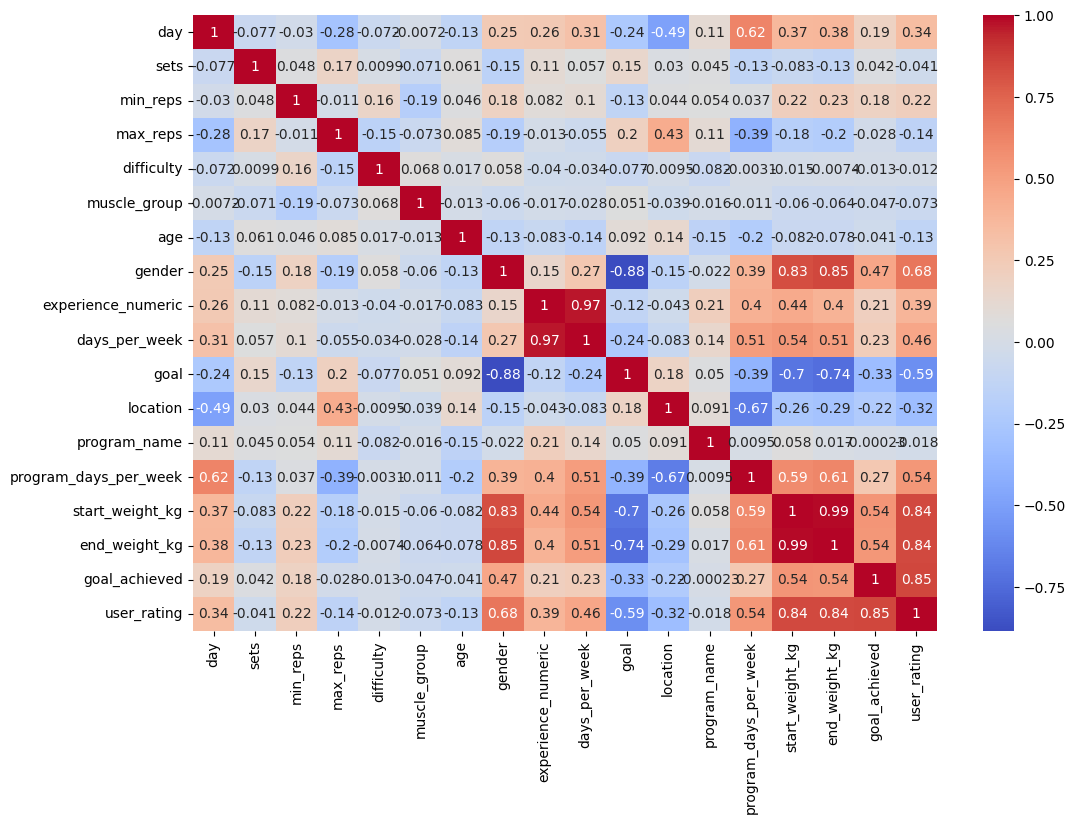

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

### 8. For generate more data use `CTGAN`.
Install `ctgan`, `sdv`

In [85]:
!pip install ctgan
!pip install sdv


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 9. Use `SingleTableMetadata` for saved information about the table

In [86]:
from ctgan import CTGAN
from sdv.evaluation.single_table import evaluate_quality
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(full_data)

### 10. Create and train `CTGAN`

In [87]:
ctgan = CTGAN(epochs=100, batch_size=500, log_frequency=False,verbose=True)

ctgan.fit(df_encoded, cat_cols)

Gen. (+00.75) | Discrim. (-00.24): 100%|█████████████████████████████████████████████| 100/100 [00:10<00:00,  9.10it/s]


### 11. Generate 20,000 new synthetic data samples using CTGAN

In [88]:
synthetic_rows = ctgan.sample(20000)

### 12. Evaluate synthetic data quality

In [89]:
quality_report = evaluate_quality(
    real_data=df_encoded,
    synthetic_data=synthetic_rows,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |████████████████████████████████████████████████████| 18/18 [00:00<00:00, 305.05it/s]|
Column Shapes Score: 90.22%

(2/2) Evaluating Column Pair Trends: |█████████████████████████████████████████████| 153/153 [00:00<00:00, 245.05it/s]|
Column Pair Trends Score: 59.99%

Overall Score (Average): 75.1%



In [90]:
synthetic_rows

,day,sets,min_reps,max_reps,difficulty,muscle_group,age,gender,experience_numeric,days_per_week,goal,location,program_name,program_days_per_week,start_weight_kg,end_weight_kg,goal_achieved,user_rating
0,23,3,11,3,0,6,25,0,1,3,1,0,12,5,86.716065,76.441119,True,3.192093
1,14,3,1,1,2,0,55,0,2,3,0,0,12,4,66.216698,81.801543,True,4.824041
2,14,3,11,0,1,9,25,1,1,3,0,1,5,4,68.404412,58.908125,True,4.419387
3,0,3,11,2,2,10,35,0,1,4,1,0,20,5,78.570102,90.306555,True,4.347397
4,14,4,1,5,2,10,21,1,2,4,0,2,8,3,64.058011,78.533991,True,4.330876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,7,3,2,0,1,2,45,0,1,3,2,0,1,4,66.329345,87.208164,True,4.995665
19996,10,4,2,2,2,7,50,1,1,6,0,0,22,5,76.134911,80.915465,True,4.896500
19997,7,3,1,1,1,9,44,0,1,6,0,0,12,2,78.226716,78.741595,True,4.722045
19998,7,4,1,2,0,12,28,1,3,6,1,0,9,4,60.958185,86.726139,True,4.687612


### 13. Synthetic data 

In [91]:
df_encoded.isnull().sum()

day                      0
sets                     0
min_reps                 0
max_reps                 0
difficulty               0
muscle_group             0
age                      0
gender                   0
experience_numeric       0
days_per_week            0
goal                     0
location                 0
program_name             0
program_days_per_week    0
start_weight_kg          0
end_weight_kg            0
goal_achieved            0
user_rating              0
dtype: int64

### 14. Combine original dataset with generated dataset

In [92]:
gym_data = pd.concat([df_encoded,synthetic_rows], ignore_index=True)

In [93]:
gym_data

,day,sets,min_reps,max_reps,difficulty,muscle_group,age,gender,experience_numeric,days_per_week,goal,location,program_name,program_days_per_week,start_weight_kg,end_weight_kg,goal_achieved,user_rating
0,0,3,11,0,1,4,23,1,1,3,0,0,5,3,78.500000,82.000000,True,4.700000
1,0,3,11,0,1,4,49,1,1,3,0,0,5,3,79.000000,82.500000,True,4.700000
2,0,3,11,0,1,4,24,1,1,3,0,0,5,3,79.500000,83.000000,True,4.800000
3,0,3,11,0,2,0,23,1,1,3,0,0,5,3,78.500000,82.000000,True,4.700000
4,0,3,11,0,2,0,49,1,1,3,0,0,5,3,79.000000,82.500000,True,4.700000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21233,7,3,2,0,1,2,45,0,1,3,2,0,1,4,66.329345,87.208164,True,4.995665
21234,10,4,2,2,2,7,50,1,1,6,0,0,22,5,76.134911,80.915465,True,4.896500
21235,7,3,1,1,1,9,44,0,1,6,0,0,12,2,78.226716,78.741595,True,4.722045
21236,7,4,1,2,0,12,28,1,3,6,1,0,9,4,60.958185,86.726139,True,4.687612


### 15. Save the new dataset


In [94]:
gym_data.to_csv('ctgan_gym.csv', index=False) 